# Hotel bar inventory forecasting and par recommendations
## Krystal Ball assessment
This notebook analyses the supplied transaction CSV, compares four forecasting approaches, recommends stock targets, and tests two inventory policies. All volumes are millilitres unless labelled otherwise. The executed results are included; **Run All** regenerates them.

**Business question:** how much stock should each bar hold for each brand to balance unavailable drinks against excess inventory? No prices or holding-cost rates were supplied, so we report volume and service outcomes, not invented financial savings.

In [1]:
from pathlib import Path
import sys, json, inspect
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if not (ROOT/'src/inventory.py').exists():
    raise RuntimeError('Open this notebook from bar_inventory_project or its notebooks folder')
sys.path.insert(0, str(ROOT/'src'))
import inventory as inv
pd.set_option('display.max_columns', 12)
raw, daily, y, pairs, audit = inv.prepare(ROOT/'data/raw/bar_inventory_data.csv')
display(pd.Series(audit, name='Data audit'))

raw_rows                                6575
duplicates_removed                         0
series                                    96
days                                     366
start                             2023-01-01
end                               2024-01-01
balance_flag_rows                        149
maximum_balance_error_ml                9.25
continuity_flag_rows                     206
missing_series_days                    28561
total_series_days                      35136
observed_zero_closing_days               416
historical_stockout_proxy_days           416
Name: Data audit, dtype: object

## 1. Data preparation and assumptions
Parse US-style timestamps explicitly. Remove exact duplicate records. Reject missing, nonnumeric, negative or nonfinite required values. Flag row balance differences above 0.02 ml but retain supplied consumption: there is no authoritative replacement. Also audit continuity between each series' consecutive logged balances.

Only observed bar-brand combinations are expanded over the common calendar. **Unlogged days are assumed to have zero consumption**, while missing balances remain missing. This is a strong completeness assumption, not an observation; the `observed` flag preserves the distinction. Items are assumed stocked over the full calendar. Product launch dates, closure calendars and extraction gaps could invalidate this assumption. Zero closing balances with prior positive consumption are stockout proxies, not proof of lost customer demand.

Consumption is fulfilled demand. Demand during a stockout is censored and cannot be recovered from this dataset alone.

In [2]:
display(raw.loc[raw.balance_flag, ['Date Time Served','Bar Name','Brand Name','balance_error_ml']].head(10))
coverage = daily.groupby('Bar Name').agg(series_days=('observed','size'), observed_days=('observed','sum'), consumption_ml=('demand','sum'))
coverage['coverage_pct'] = 100*coverage.observed_days/coverage.series_days
display(coverage)
display(daily.groupby('observed').agg(days=('demand','size'), mean_consumption_ml=('demand','mean')))
display(daily.loc[daily.stockout_proxy, ['date','Bar Name','Brand Name','closing']].head())

,Date Time Served,Bar Name,Brand Name,balance_error_ml
42,1/3/2023 20:00,Brown's Bar,Jim Beam,0.47
58,1/4/2023 10:45,Smith's Bar,Miller,0.78
99,1/6/2023 13:10,Johnson's Bar,Barefoot,-1.07
125,1/7/2023 14:01,Taylor's Bar,Jim Beam,5.32
143,1/8/2023 14:46,Taylor's Bar,Captain Morgan,3.40
174,1/9/2023 10:09,Thomas's Bar,Jameson,0.18
162,1/9/2023 13:49,Brown's Bar,Coors,-4.47
179,1/10/2023 20:13,Smith's Bar,Coors,3.30
251,1/13/2023 17:21,Anderson's Bar,Jim Beam,-2.62
245,1/13/2023 22:04,Brown's Bar,Budweiser,-1.47


,series_days,observed_days,consumption_ml,coverage_pct
Bar Name,,,,
Anderson's Bar,5856,1102,335818.95,18.818306
Brown's Bar,5856,1100,326371.92,18.784153
Johnson's Bar,5856,1106,344184.38,18.886612
Smith's Bar,5856,1078,328713.91,18.408470
Taylor's Bar,5856,1088,315176.56,18.579235
Thomas's Bar,5856,1101,318415.94,18.801230


,days,mean_consumption_ml
observed,,
False,28561,0.000000
True,6575,299.419264


,date,Bar Name,Brand Name,closing
430,2023-03-06,Anderson's Bar,Bacardi,0.0
443,2023-03-19,Anderson's Bar,Bacardi,0.0
1368,2023-09-28,Anderson's Bar,Budweiser,0.0
1372,2023-10-02,Anderson's Bar,Budweiser,0.0
1375,2023-10-05,Anderson's Bar,Budweiser,0.0


## 2. EDA and temporal evaluation
ABC classes rank pre-test consumption volume (80% / 95% cumulative boundaries), not monetary value. Explore weekdays rather than assuming that Friday and Saturday are busier.

Use the first 60% of calendar days for training, the next 20% for model selection, and the final 20% for test reporting. Within validation/test, forecast from weekly rolling origins for up to seven days. Every lag and rolling feature is calculated from earlier history within its own series. Multi-day Random Forest predictions are recursive, with no future actuals within a forecast block.

Compare a 14-day mean, weekly seasonal naive, additive weekly Holt-Winters with fixed smoothing coefficients (0.2 level, 0.1 seasonal; not tuned), and pooled Random Forest (60 trees, depth 10, minimum leaf 30). The series index is an identity proxy with an arbitrary ordinal ordering; one-hot or hierarchical encodings are a future improvement. Forest training is fixed within each evaluation segment and refreshed at the test boundary. Model choice uses validation WAPE only. WAPE is undefined when total actual demand is zero; MAE remains usable.

In [3]:
print(inspect.getsource(inv.features))
print(inspect.getsource(inv.evaluate))
results = inv.run()

def features(history, date):
    # history is time x series; every feature uses strictly earlier observations.
    h = np.asarray(history)
    n = h.shape[1]
    return np.column_stack([np.arange(n), h[-1], h[-7], h[-14], h[-7:].mean(0),
        h[-14:].mean(0), h[-7:].std(0), np.full(n, date.dayofweek)])

def evaluate(y, start, end, rf):
    """Weekly origins, seven-day recursive forecasts; no future actuals in a block."""
    predictions = {m: [] for m in MODELS}
    for origin in range(start, end, 7):
        dates = y.index[origin:min(origin+7, end)]
        for model in MODELS:
            predictions[model].append(forecast(y.iloc[:origin], dates, model, rf))
    return {m: np.vstack(p) for m, p in predictions.items()}



Training and validation...


Selected: mean_14 ; evaluating untouched test period...


     split          model    MAE_ml    RMSE_ml     WAPE
validation        mean_14 90.141244 143.792192 1.675718
validation seasonal_naive 95.337784 197.816117 1.772321
validation   holt_winters 92.980114 149.963579 1.728492
validation  random_forest 91.912754 139.673227 1.708650
      test        mean_14 93.193481 148.804013 1.672837
      test seasonal_naive 97.527186 203.597163 1.750627
      test   holt_winters 95.329401 153.968691 1.711177
      test  random_forest 93.694322 144.246516 1.681827
                 policy  stockout_series_days  lost_volume_ml  fill_rate  mean_closing_ml_per_series  period_turnover
      Fixed 7-day stock                   527    92899.567192   0.765265                  308.104555        10.239464
Forecast + safety stock                   373    66305.773496   0.832461                  389.602511         8.808578


,split,model,MAE_ml,RMSE_ml,WAPE
0,validation,mean_14,90.1412,143.7922,1.6757
1,validation,seasonal_naive,95.3378,197.8161,1.7723
2,validation,holt_winters,92.9801,149.9636,1.7285
3,validation,random_forest,91.9128,139.6732,1.7087
4,test,mean_14,93.1935,148.8040,1.6728
5,test,seasonal_naive,97.5272,203.5972,1.7506
6,test,holt_winters,95.3294,153.9687,1.7112
7,test,random_forest,93.6943,144.2465,1.6818


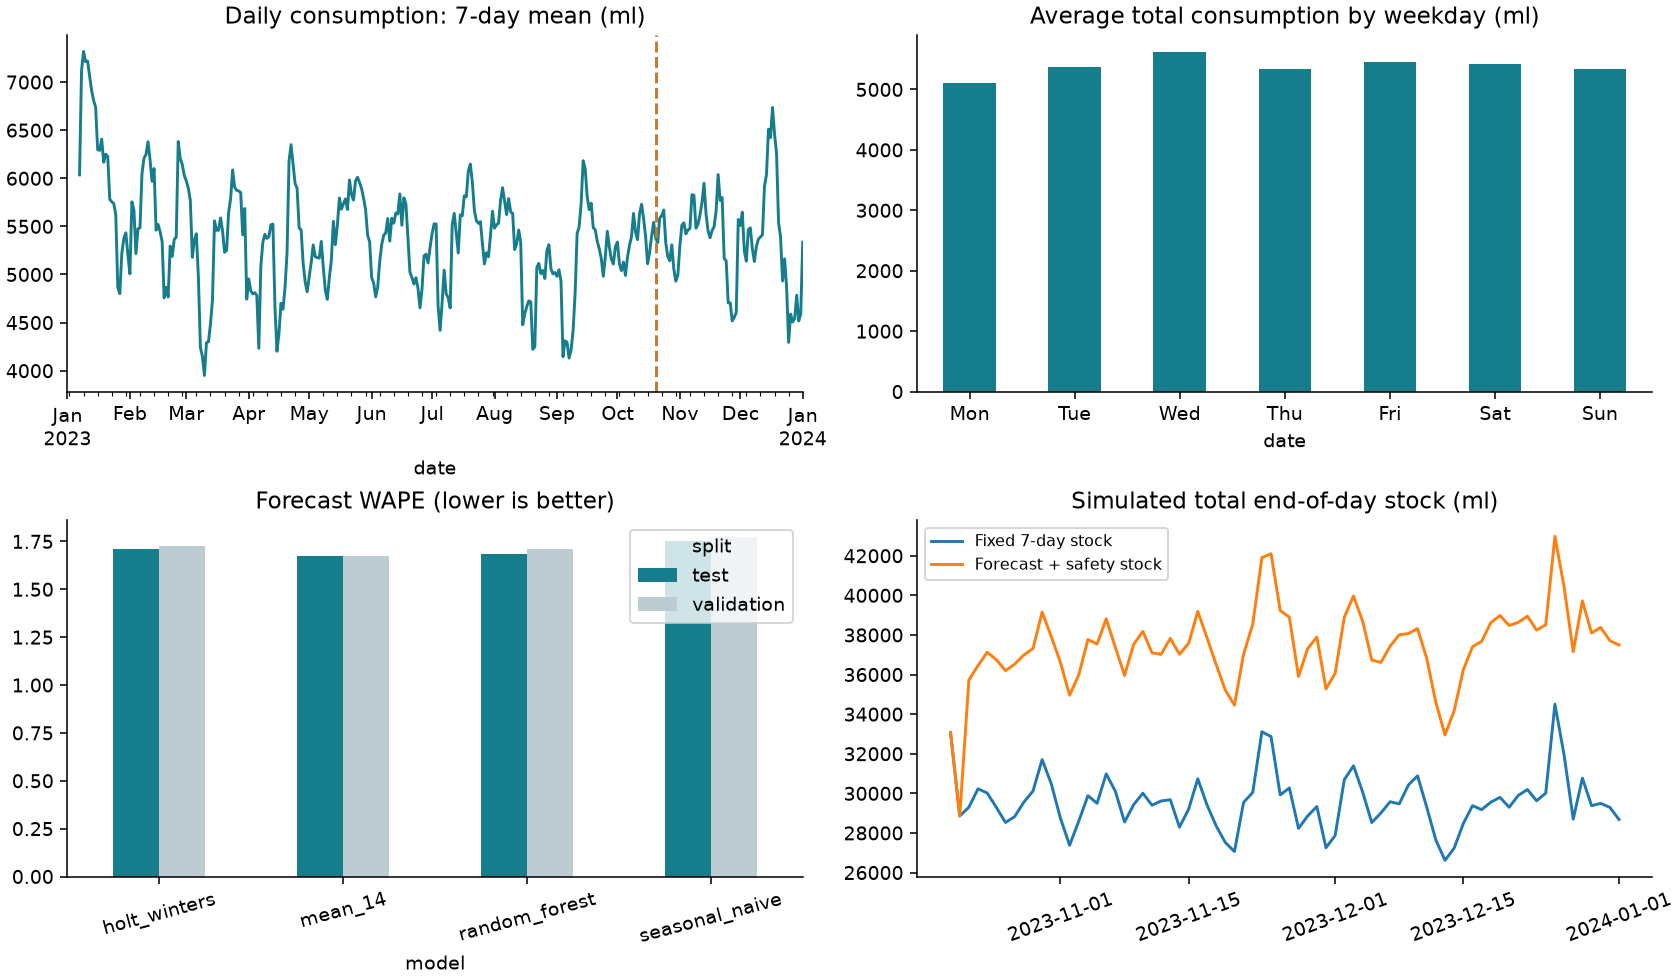

,Bar Name,Brand Name,consumption_ml,class
0,Brown's Bar,Yellow Tail,24021.42,A
1,Johnson's Bar,Captain Morgan,23218.21,A
2,Anderson's Bar,Barefoot,22784.94,A
3,Johnson's Bar,Smirnoff,22339.01,A
4,Taylor's Bar,Grey Goose,22225.78,A
5,Smith's Bar,Absolut,21987.86,A
6,Anderson's Bar,Captain Morgan,21880.56,A
7,Johnson's Bar,Absolut,21523.35,A
8,Brown's Bar,Grey Goose,21469.64,A
9,Anderson's Bar,Bacardi,21260.12,A


,Bar Name,Brand Name,series,MAE_ml,WAPE
28,Brown's Bar,Miller,28,51.818282,2.437345
76,Taylor's Bar,Miller,76,57.760492,2.392515
20,Brown's Bar,Captain Morgan,20,61.300907,2.334347
60,Smith's Bar,Miller,60,82.116776,2.331109
12,Anderson's Bar,Miller,12,64.054363,2.308513
65,Taylor's Bar,Bacardi,65,62.345039,2.069944
11,Anderson's Bar,Malibu,11,42.404305,2.053692
71,Taylor's Bar,Heineken,71,40.989180,2.029520
19,Brown's Bar,Budweiser,19,68.503514,1.987181
53,Smith's Bar,Coors,53,59.145425,1.975269


In [4]:
display(results['metrics'].round(4))
display(Image(filename=str(ROOT/'outputs/assessment_overview.png')))
display(pd.read_csv(ROOT/'outputs/abc_classification.csv').head(12))
display(pd.read_csv(ROOT/'outputs/test_metrics_by_series.csv').sort_values('WAPE',ascending=False).head(10))

## 3. Inventory decision and simulation
At the end of day t, forecast consumption for t+1 through t+L using data available through t. Default supplier lead time L=2 days. **Par = sum of lead-time forecasts + 1.645 × validation RMSE × sqrt(L)**. The RMSE is per series and is frozen before the test. The normal approximation and independent daily errors are simplifications; 1.645 is a nominal 95% one-sided factor, not a guaranteed fill rate.

Each morning receive due orders, fulfil demand, and record lost volume. At day end, compute inventory position = on-hand + on-order, then order max(0, par - inventory position). An order placed at the end of t arrives before demand at t+L. Thus L=1 means next morning and the target covers L future daily demands under this convention. Reorder threshold equals the target (daily order-up-to policy).

Compare an assumed fixed seven-day-mean target with the forecast-and-buffer policy, using identical initial stock and no initial pipeline. This is not a reconstruction of the hotel's undocumented current ordering rules. There is no warm-up exclusion. The same recorded demand stream drives both policies. Previous recorded consumption remains observable in the replay even if a simulated policy would have lost it: this is a historical scenario comparison, not a live censored-feedback experiment.

Orders are continuous ml to isolate the policy. 750 ml bottle rounding appears only in the recommendation export and is not included in the backtest. No expiry, minimum order, capacity, supplier variability or purchasing costs are modelled.

In [5]:
print(inspect.getsource(inv.simulate))
display(results['policies'].round(3))
display(pd.read_csv(ROOT/'outputs/sensitivity.csv').round(3))

def simulate(actual, targets, lead_time=2, initial=None):
    """Daily end-of-day review; receive before demand; orders arrive t+L.

    targets[t] covers future days t+1..t+L (L=1 arrives next morning).
    Inventory position includes all outstanding orders. Unmet demand is lost.
    """
    a, targets = np.asarray(actual), np.asarray(targets)
    if lead_time < 1 or a.shape != targets.shape or (a < 0).any() or (targets < 0).any():
        raise ValueError('Invalid simulation input')
    stock = np.array(initial if initial is not None else targets[0], dtype=float).copy()
    if (stock < 0).any():
        raise ValueError('Negative initial stock')
    pending = {}
    records = []
    for t, demand in enumerate(a):
        received = pending.pop(t, np.zeros_like(stock))
        stock += received
        opening = stock.copy()
        served = np.minimum(stock, demand)
        lost = demand-served
        stock -= served
        pipeline = sum(pending.values(), np.zeros_like(stock))
   

,policy,stockout_series_days,lost_volume_ml,fill_rate,mean_closing_ml_per_series,period_turnover
0,Fixed 7-day stock,527,92899.567,0.765,308.105,10.239
1,Forecast + safety stock,373,66305.773,0.832,389.603,8.809


,lead_days,z,stockout_series_days,lost_volume_ml,fill_rate,mean_closing_ml_per_series,period_turnover
0,1,1.282,693,129076.389,0.674,237.538,11.695
1,1,1.645,606,99200.434,0.749,278.910,11.076
2,1,2.326,409,56230.588,0.858,359.903,9.827
3,2,1.282,474,88957.139,0.775,329.823,9.690
4,2,1.645,373,66305.773,0.832,389.603,8.809
5,2,2.326,217,37656.357,0.905,510.562,7.306
6,3,1.282,384,74061.852,0.813,407.778,8.218
7,3,1.645,280,55052.757,0.861,482.347,7.358
8,3,2.326,158,33210.632,0.916,630.792,5.987


## 4. Operational recommendations
The CSV below lists historical as-of targets for every bar-brand pair. It is based on the final date in the supplied data, not today's date. Managers must verify actual on-hand and outstanding orders before applying the inventory-position rule. Do not subtract a stale recorded balance to generate a purchase order.

`period_turnover` = total fulfilled test-period volume / mean aggregate closing stock; it is not annualised. A stockout count is a bar-brand-day with positive unmet demand, not a calendar-day total. Inventory levels are a service/holding tradeoff: do not claim both improve unless the results show that.

In [6]:
display(results['recommendations'].round(2).head(16))
print('All 96 recommendations: outputs/par_recommendations.csv')

,Bar Name,Brand Name,series,as_of,lead_time_demand_ml,safety_stock_ml,par_ml,par_750ml_bottles
0,Anderson's Bar,Absolut,0,2024-01-01,0.00,162.75,162.75,1
1,Anderson's Bar,Bacardi,1,2024-01-01,330.38,351.85,682.23,1
2,Anderson's Bar,Barefoot,2,2024-01-01,89.24,500.66,589.91,1
3,Anderson's Bar,Budweiser,3,2024-01-01,0.00,267.27,267.27,1
4,Anderson's Bar,Captain Morgan,4,2024-01-01,39.84,427.27,467.11,1
5,Anderson's Bar,Coors,5,2024-01-01,150.91,265.31,416.22,1
6,Anderson's Bar,Grey Goose,6,2024-01-01,77.27,337.97,415.24,1
7,Anderson's Bar,Heineken,7,2024-01-01,138.09,265.74,403.84,1
8,Anderson's Bar,Jack Daniels,8,2024-01-01,116.90,333.03,449.93,1
9,Anderson's Bar,Jameson,9,2024-01-01,103.31,353.52,456.83,1


All 96 recommendations: outputs/par_recommendations.csv


## 5. Deployment, limitations and next steps
Validate logging completeness and stockout censoring before deployment. Reconcile balances with POS/stocktake data. Run a daily pipeline with schema and freshness checks, forecast refresh, and manager-reviewed recommendations. Track forecast errors, service, stock levels, override frequency and actual lead times. Use chronological rolling evaluation when retraining.

First improvements: stock availability and unfulfilled-request logs; bottle sizes and case-pack constraints; actual delivery calendars; promotions, occupancy and holidays; intermittent-demand models and empirical lead-time error quantiles. Stress-test supplier delays and correlated demand. Unknown series need a documented cold-start rule before production.

Source: supplied `Consumption Dataset - Dataset.csv`, copied unchanged under `data/raw/`. Assignment: supplied reference document and screenshot. See the two-page report and four-minute video outline for the managerial summary.

**Accuracy caveat:** An all-zero forecast has 100% WAPE here, lower than all four candidate models, but would offer no useful stock coverage. Selection is best among the tested candidates only. Validate missing logs and evaluate weekly aggregation before operational use.